# 75 - InternVL2.5-8B とモデル比較総括

## 概要
InternVL2.5-8B を2つ目の大規模VLMとして評価し、Notebook 72-74 の全キャプションモデルの総合比較を実施する。

## InternVL2.5-8B の特徴
- **InternViT-6B** 画像エンコーダ + **InternLM2-Chat-7B** LLM
- **多言語対応**: 英語、中国語、日本語など多言語に対応
- **動的解像度**: 画像を448×448タイルに分割して処理（最大12タイル）
- **VRAM**: ~18GB (fp16)

## 評価
- Self-Retrieval Score（SigLIP 2 Large でキャプションをembed → 画像embeddingとの類似度）
- Retrieval Rank テスト（キャプション → 元画像の検索順位）
- 全モデル（BLIP-2, Florence-2, Qwen2.5-VL, InternVL2.5）の総合比較
- レーダーチャートによる多角的比較
- カテゴリ別比較ヒートマップ

## 使用モデル
- キャプション生成: `OpenGVLab/InternVL2_5-8B` (~18GB fp16)
- 評価: SigLIP 2 Large (`google/siglip2-large-patch16-256`)

In [1]:
import json
import time
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torchvision.transforms as T
from PIL import Image
from tqdm.notebook import tqdm
from transformers import AutoModel, AutoTokenizer

## 1. 設定とデータ読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
INTERNVL_MODEL = "OpenGVLab/InternVL2_5-8B"
SIGLIP2_MODEL = "google/siglip2-large-patch16-256"

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
""").fetchdf()

# SigLIP 2 Large の画像埋め込みを読み込み（評価用）
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [SIGLIP2_MODEL]).fetchdf()
conn.close()

image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)

print(f"Total images: {len(catalog_df)}")
print(f"Image embeddings: {image_embeddings.shape}")
print(f"\nCategories:")
for cat, count in catalog_df['category'].value_counts().items():
    print(f"  {cat}: {count}")

Total images: 378
Image embeddings: (378, 1024)

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


## 2. InternVL2.5-8B モデルの読み込み

In [3]:
print(f"Loading InternVL2.5-8B model: {INTERNVL_MODEL}")
print("This may take several minutes for the first download (~18GB)...")

tokenizer = AutoTokenizer.from_pretrained(INTERNVL_MODEL, trust_remote_code=True)
model = AutoModel.from_pretrained(
    INTERNVL_MODEL,
    torch_dtype=torch.float16,
    trust_remote_code=True,
    device_map="auto",
)
model.eval()

print(f"Model loaded.")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

Loading InternVL2.5-8B model: OpenGVLab/InternVL2_5-8B
This may take several minutes for the first download (~18GB)...


Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


`torch_dtype` is deprecated! Use `dtype` instead!


Unrecognized keys in `rope_parameters` for 'rope_type'='dynamic': {'rope_theta'}


/home/terapyon/dev/vibe-coding/image-vector-poc/.venv/lib/python3.13/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention2 is not installed.


Loading weights:   0%|          | 0/573 [00:00<?, ?it/s]

Model loaded.
GPU memory allocated: 15.5 GB


## 3. InternVL2.5 画像前処理とキャプション生成関数

In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def build_transform(input_size=448):
    """InternVL2.5 用の画像前処理パイプラインを構築する。"""
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=T.InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])


def load_image_for_internvl(image, input_size=448, max_num=12):
    """PIL画像をInternVL2.5の入力形式に変換する。"""
    transform = build_transform(input_size=input_size)
    pixel_values = transform(image).unsqueeze(0)
    return pixel_values


def generate_caption_internvl(image, prompt, max_new_tokens=256):
    """InternVL2.5-8B でキャプションを生成する。"""
    pixel_values = load_image_for_internvl(image).to(torch.float16).cuda()
    generation_config = dict(max_new_tokens=max_new_tokens)
    response = model.chat(tokenizer, pixel_values, prompt, generation_config)
    return response


# テスト
test_img = Image.open(catalog_df.iloc[0]['file_path']).convert('RGB')
test_caption = generate_caption_internvl(test_img, "Describe this image in one sentence.")
print(f"Test (EN): {test_caption}")

test_caption_ja = generate_caption_internvl(test_img, "この画像を日本語で一文で説明してください。")
print(f"Test (JA): {test_caption_ja}")

Test (EN): _TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI plots_TRI plots_TRI plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plot

Test (JA): _TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI plots_TRI plots_TRI plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots plots摸摸 plots摸摸 pl

## 4. 日英キャプション生成

4つのプロンプトで全画像のキャプションを生成する:
1. **英語・簡潔**: "Describe this image in one sentence."
2. **英語・詳細**: "Describe this image in detail."
3. **日本語・簡潔**: "この画像を日本語で一文で説明してください。"
4. **日本語・詳細**: "この画像を日本語で詳しく説明してください。"

In [5]:
prompt_configs = {
    "en_brief": "Describe this image in one sentence.",
    "en_detailed": "Describe this image in detail.",
    "ja_brief": "この画像を日本語で一文で説明してください。",
    "ja_detailed": "この画像を日本語で詳しく説明してください。",
}

all_captions = {key: [] for key in prompt_configs}

print(f"Generating captions for {len(catalog_df)} images x {len(prompt_configs)} prompts...")
start_time = time.time()

for idx in tqdm(range(len(catalog_df)), desc="Captioning"):
    row = catalog_df.iloc[idx]
    img = Image.open(row['file_path']).convert('RGB')
    
    for key, prompt in prompt_configs.items():
        caption = generate_caption_internvl(img, prompt)
        all_captions[key].append(caption)

elapsed = time.time() - start_time
print(f"\nTotal time: {elapsed:.1f}s ({elapsed/len(catalog_df):.2f}s per image)")
print(f"Speed: {len(catalog_df) / elapsed:.2f} images/sec (all prompts)")

Generating captions for 378 images x 4 prompts...


Captioning:   0%|          | 0/378 [00:00<?, ?it/s]


Total time: 10077.3s (26.66s per image)
Speed: 0.04 images/sec (all prompts)


In [6]:
# サンプルキャプション表示
print("=" * 80)
print("Sample Captions (InternVL2.5-8B)")
print("=" * 80)

for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:2]
    print(f"\n--- {cat} ---")
    for idx in cat_indices:
        print(f"  [{catalog_df.iloc[idx]['file_name']}]")
        for key in prompt_configs:
            cap = all_captions[key][idx]
            print(f"    {key:15s}: {cap[:120]}")
        print()

Sample Captions (InternVL2.5-8B)

--- terada ---
  [terada-202205-pyconjp-4-3-900.jpg]
    en_brief       : _TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI
    en_detailed    : _TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI
    ja_brief       : _TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI
    ja_detailed    : _TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI_TRI

  [terada-uspycon2019-up.jpg]
    en_brief       : 尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的
    en_detailed    : 尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的尴尬的
    ja_brief       : 尴尬的尴尬的尴尬的

In [7]:
# キャプション統計
print("=" * 60)
print("Caption Statistics")
print("=" * 60)

for key in prompt_configs:
    captions = all_captions[key]
    char_lengths = [len(c) for c in captions]
    unique_ratio = len(set(captions)) / len(captions)
    print(f"\n{key}:")
    print(f"  Char count — Mean: {np.mean(char_lengths):.1f}, Std: {np.std(char_lengths):.1f}, "
          f"Min: {np.min(char_lengths)}, Max: {np.max(char_lengths)}")
    print(f"  Unique captions: {len(set(captions))} / {len(captions)} ({unique_ratio*100:.1f}%)")

Caption Statistics

en_brief:
  Char count — Mean: 1231.7, Std: 499.2, Min: 256, Max: 2411
  Unique captions: 346 / 378 (91.5%)

en_detailed:
  Char count — Mean: 1231.2, Std: 499.3, Min: 256, Max: 2419
  Unique captions: 346 / 378 (91.5%)

ja_brief:
  Char count — Mean: 1230.8, Std: 494.7, Min: 256, Max: 2397
  Unique captions: 351 / 378 (92.9%)

ja_detailed:
  Char count — Mean: 1231.1, Std: 494.8, Min: 256, Max: 2398
  Unique captions: 350 / 378 (92.6%)


## 5. InternVL モデルのGPUメモリ解放 → 評価モデル読み込み

In [8]:
del model, tokenizer
torch.cuda.empty_cache()
print("InternVL2.5-8B model released.")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

InternVL2.5-8B model released.
GPU memory allocated: 0.0 GB


In [9]:
# SigLIP 2 Large で評価
from image_vector_poc import SigLIP2Embedder

embedder = SigLIP2Embedder(model_name=SIGLIP2_MODEL, device="cuda")
print(f"Loaded: {embedder.model_name} (dim={embedder.embedding_dim})")

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded: google/siglip2-large-patch16-256 (dim=1024)


## 6. Self-Retrieval Score

In [10]:
# 各プロンプトのキャプションをembed
caption_embeddings = {}

for key in prompt_configs:
    print(f"Embedding {key} captions...")
    emb = embedder.embed_texts(all_captions[key])
    caption_embeddings[key] = emb

print("Done.")

Embedding en_brief captions...


Embedding en_detailed captions...


Embedding ja_brief captions...


Embedding ja_detailed captions...


Done.


In [11]:
# Self-Retrieval Score
self_retrieval = {}

print("=" * 60)
print("Self-Retrieval Score (InternVL2.5-8B Captions)")
print("=" * 60)

for key in prompt_configs:
    scores = np.array([
        np.dot(image_embeddings_norm[i], caption_embeddings[key][i])
        for i in range(len(catalog_df))
    ])
    self_retrieval[key] = scores
    
    print(f"\n{key}:")
    print(f"  Mean:  {scores.mean():.4f}")
    print(f"  Std:   {scores.std():.4f}")
    print(f"  Min:   {scores.min():.4f}")
    print(f"  Max:   {scores.max():.4f}")

Self-Retrieval Score (InternVL2.5-8B Captions)

en_brief:
  Mean:  0.0500
  Std:   0.0158
  Min:   -0.0181
  Max:   0.0853

en_detailed:
  Mean:  0.0497
  Std:   0.0159
  Min:   -0.0170
  Max:   0.0853

ja_brief:
  Mean:  0.0510
  Std:   0.0152
  Min:   -0.0046
  Max:   0.1107

ja_detailed:
  Mean:  0.0510
  Std:   0.0154
  Min:   -0.0046
  Max:   0.1058


In [12]:
# カテゴリ別
print("\n" + "=" * 80)
print("Self-Retrieval Score by Category")
print("=" * 80)

sr_df = pd.DataFrame({
    'category': catalog_df['category'],
    **{key: self_retrieval[key] for key in prompt_configs}
})

cat_sr = sr_df.groupby('category')[list(prompt_configs.keys())].mean()
display(cat_sr.round(4))


Self-Retrieval Score by Category


,en_brief,en_detailed,ja_brief,ja_detailed
category,,,,
EuroPython2025,0.0493,0.0486,0.0513,0.0511
KashiwaVillagePark2026,0.0414,0.0414,0.0412,0.0410
PyConJP2025,0.0495,0.0492,0.0503,0.0502
PyConJP2025-PreCampHiroshima,0.0550,0.0556,0.0557,0.0561
TokyoNight202505,0.0533,0.0529,0.0539,0.0539
terada,0.0662,0.0655,0.0663,0.0670


## 7. Retrieval Rank テスト

In [13]:
# 全プロンプトで Retrieval Rank テスト
print("=" * 60)
print("Retrieval Rank (Caption → Original Image)")
print("=" * 60)

retrieval_results = {}

for key in ['en_brief', 'ja_brief', 'en_detailed', 'ja_detailed']:
    sim_matrix = np.dot(caption_embeddings[key], image_embeddings_norm.T)
    
    ranks = []
    for i in range(len(catalog_df)):
        sorted_indices = np.argsort(sim_matrix[i])[::-1]
        rank = np.where(sorted_indices == i)[0][0] + 1
        ranks.append(rank)
    
    ranks = np.array(ranks)
    retrieval_results[key] = ranks
    
    print(f"\n{key}:")
    print(f"  Mean Rank:    {ranks.mean():.1f}")
    print(f"  Median Rank:  {np.median(ranks):.0f}")
    print(f"  Rank@1:  {(ranks == 1).sum()} / {len(catalog_df)} ({(ranks == 1).mean()*100:.1f}%)")
    print(f"  Rank<=5:  {(ranks <= 5).sum()} ({(ranks <= 5).mean()*100:.1f}%)")
    print(f"  MRR: {(1.0 / ranks).mean():.4f}")

Retrieval Rank (Caption → Original Image)

en_brief:
  Mean Rank:    183.7
  Median Rank:  171
  Rank@1:  1 / 378 (0.3%)
  Rank<=5:  3 (0.8%)
  MRR: 0.0169

ja_brief:
  Mean Rank:    182.8
  Median Rank:  176
  Rank@1:  1 / 378 (0.3%)
  Rank<=5:  3 (0.8%)
  MRR: 0.0170

en_detailed:
  Mean Rank:    184.5
  Median Rank:  176
  Rank@1:  1 / 378 (0.3%)
  Rank<=5:  3 (0.8%)
  MRR: 0.0168

ja_detailed:
  Mean Rank:    183.4
  Median Rank:  176
  Rank@1:  1 / 378 (0.3%)
  Rank<=5:  3 (0.8%)
  MRR: 0.0170


## 8. 全モデルの結果読み込みと比較

Notebook 72（BLIP-2）、73（Florence-2）、74（Qwen2.5-VL）の結果を読み込み、
InternVL2.5-8B と合わせて4モデルの総合比較を行う。

In [14]:
# 前のノートブックの結果を読み込み
eval_dir = Path("../data/evaluations")

prev_results = {}

# NB72: BLIP-2
files_72 = sorted(eval_dir.glob("72_blip2_*.json"))
if files_72:
    with open(files_72[-1]) as f:
        prev_results[72] = json.load(f)
    print(f"Loaded NB72 (BLIP-2): {files_72[-1].name}")
else:
    print("NB72 results not found.")

# NB73: Florence-2
files_73 = sorted(eval_dir.glob("73_florence2_*.json"))
if files_73:
    with open(files_73[-1]) as f:
        prev_results[73] = json.load(f)
    print(f"Loaded NB73 (Florence-2): {files_73[-1].name}")
else:
    print("NB73 results not found.")

# NB74: Qwen2.5-VL
files_74 = sorted(eval_dir.glob("74_qwen25vl_*.json"))
if files_74:
    with open(files_74[-1]) as f:
        prev_results[74] = json.load(f)
    print(f"Loaded NB74 (Qwen2.5-VL): {files_74[-1].name}")
else:
    print("NB74 results not found.")

print(f"\nLoaded results from {len(prev_results)} previous notebooks.")

Loaded NB72 (BLIP-2): 72_blip2_captioning_2026-02-19.json
NB73 results not found.
Loaded NB74 (Qwen2.5-VL): 74_qwen25vl_captioning_2026-02-19.json

Loaded results from 2 previous notebooks.


In [15]:
# 総合比較テーブルの構築
print("=" * 100)
print("Comprehensive Model Comparison: BLIP-2 vs Florence-2 vs Qwen2.5-VL vs InternVL2.5")
print("=" * 100)

# InternVL の最良モード
internvl_best_en = max(['en_brief', 'en_detailed'], key=lambda k: self_retrieval[k].mean())
internvl_best_ja = max(['ja_brief', 'ja_detailed'], key=lambda k: self_retrieval[k].mean())

# 各モデルの指標を収集
comparison_data = []

# BLIP-2
if 72 in prev_results:
    d = prev_results[72]
    best_mode = d.get('best_mode', 'unconditional')
    comparison_data.append({
        'Model': 'BLIP-2',
        'Notebook': '72',
        'SR (EN best)': d['self_retrieval'][best_mode]['mean'],
        'SR (JA best)': None,
        'MRR (EN)': d['retrieval_rank']['mrr'],
        'MRR (JA)': None,
        'Speed (img/s)': d.get('speed_captions_per_sec', d['total_images'] / d['processing_time_seconds']),
        'VRAM (GB)': '~6',
        'JA support': 'No',
    })

# Florence-2
if 73 in prev_results:
    d = prev_results[73]
    best_gran = d.get('best_granularity', 'more_detailed')
    comparison_data.append({
        'Model': 'Florence-2',
        'Notebook': '73',
        'SR (EN best)': d['self_retrieval'][best_gran]['mean'],
        'SR (JA best)': None,
        'MRR (EN)': d['retrieval_rank']['mrr'],
        'MRR (JA)': None,
        'Speed (img/s)': d.get('speed_captions_per_sec', d['total_images'] / d['processing_time_seconds']),
        'VRAM (GB)': '~1.5',
        'JA support': 'No',
    })

# Qwen2.5-VL
if 74 in prev_results:
    d = prev_results[74]
    # Qwen のEN/JAベスト
    en_modes = [k for k in d['self_retrieval'] if k.startswith('en_')]
    ja_modes = [k for k in d['self_retrieval'] if k.startswith('ja_')]
    qwen_best_en = max(en_modes, key=lambda k: d['self_retrieval'][k]['mean']) if en_modes else None
    qwen_best_ja = max(ja_modes, key=lambda k: d['self_retrieval'][k]['mean']) if ja_modes else None
    
    # Retrieval Rank の MRR
    rr = d.get('retrieval_rank', {})
    qwen_mrr_en = rr.get(qwen_best_en, {}).get('mrr', rr.get('mrr', None)) if qwen_best_en else None
    qwen_mrr_ja = rr.get(qwen_best_ja, {}).get('mrr', None) if qwen_best_ja else None
    
    comparison_data.append({
        'Model': 'Qwen2.5-VL',
        'Notebook': '74',
        'SR (EN best)': d['self_retrieval'][qwen_best_en]['mean'] if qwen_best_en else None,
        'SR (JA best)': d['self_retrieval'][qwen_best_ja]['mean'] if qwen_best_ja else None,
        'MRR (EN)': qwen_mrr_en,
        'MRR (JA)': qwen_mrr_ja,
        'Speed (img/s)': d['total_images'] / d['processing_time_seconds'],
        'VRAM (GB)': '~15',
        'JA support': 'Yes',
    })

# InternVL2.5-8B（本ノートブック）
internvl_mrr_en = float((1.0 / retrieval_results[internvl_best_en]).mean())
internvl_mrr_ja = float((1.0 / retrieval_results[internvl_best_ja]).mean())

comparison_data.append({
    'Model': 'InternVL2.5-8B',
    'Notebook': '75',
    'SR (EN best)': float(self_retrieval[internvl_best_en].mean()),
    'SR (JA best)': float(self_retrieval[internvl_best_ja].mean()),
    'MRR (EN)': internvl_mrr_en,
    'MRR (JA)': internvl_mrr_ja,
    'Speed (img/s)': len(catalog_df) / elapsed,
    'VRAM (GB)': '~18',
    'JA support': 'Yes',
})

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# テキスト形式でも出力
print(f"\n{'Model':<20} {'SR(EN)':>10} {'SR(JA)':>10} {'MRR(EN)':>10} {'MRR(JA)':>10} {'img/s':>8} {'VRAM':>8} {'JA':>5}")
print("-" * 90)
for _, row in comparison_df.iterrows():
    sr_en = f"{row['SR (EN best)']:.4f}" if row['SR (EN best)'] is not None else '—'
    sr_ja = f"{row['SR (JA best)']:.4f}" if row['SR (JA best)'] is not None else '—'
    mrr_en = f"{row['MRR (EN)']:.4f}" if row['MRR (EN)'] is not None else '—'
    mrr_ja = f"{row['MRR (JA)']:.4f}" if row['MRR (JA)'] is not None else '—'
    speed = f"{row['Speed (img/s)']:.2f}" if row['Speed (img/s)'] is not None else '—'
    print(f"{row['Model']:<20} {sr_en:>10} {sr_ja:>10} {mrr_en:>10} {mrr_ja:>10} {speed:>8} {row['VRAM (GB)']:>8} {row['JA support']:>5}")

Comprehensive Model Comparison: BLIP-2 vs Florence-2 vs Qwen2.5-VL vs InternVL2.5


,Model,Notebook,SR (EN best),SR (JA best),MRR (EN),MRR (JA),Speed (img/s),VRAM (GB),JA support
0,BLIP-2,72,0.161005,NaN,0.435161,NaN,2.616105,~6,No
1,Qwen2.5-VL,74,0.179712,0.137525,0.634995,0.317573,0.032337,~15,Yes
2,InternVL2.5-8B,75,0.050000,0.050997,0.016910,0.016998,0.037510,~18,Yes



Model                    SR(EN)     SR(JA)    MRR(EN)    MRR(JA)    img/s     VRAM    JA
------------------------------------------------------------------------------------------
BLIP-2                   0.1610        nan     0.4352        nan     2.62       ~6    No
Qwen2.5-VL               0.1797     0.1375     0.6350     0.3176     0.03      ~15   Yes
InternVL2.5-8B           0.0500     0.0510     0.0169     0.0170     0.04      ~18   Yes


## 9. レーダーチャート（全4モデル比較）

Self-Retrieval Score、Retrieval MRR、速度、日本語対応などを
レーダーチャートで多角的に比較する。

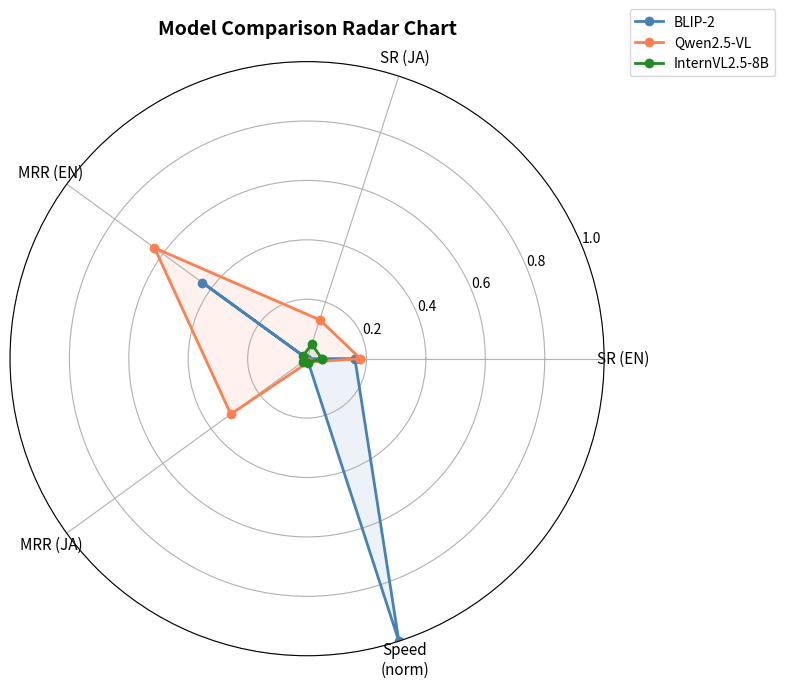

Saved: data/75_model_comparison_radar.png


In [16]:
# レーダーチャートの作成
# 指標: SR(EN), SR(JA), MRR(EN), MRR(JA), Speed (正規化)

radar_labels = ['SR (EN)', 'SR (JA)', 'MRR (EN)', 'MRR (JA)', 'Speed\n(norm)']
n_metrics = len(radar_labels)

# 最大速度で正規化
max_speed = max(row['Speed (img/s)'] for row in comparison_data if row['Speed (img/s)'] is not None)

radar_data = {}
for row in comparison_data:
    name = row['Model']
    values = [
        row['SR (EN best)'] if row['SR (EN best)'] is not None else 0,
        row['SR (JA best)'] if row['SR (JA best)'] is not None else 0,
        row['MRR (EN)'] if row['MRR (EN)'] is not None else 0,
        row['MRR (JA)'] if row['MRR (JA)'] is not None else 0,
        (row['Speed (img/s)'] / max_speed) if row['Speed (img/s)'] is not None else 0,
    ]
    radar_data[name] = values

# 角度の計算
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]  # 閉じる

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['steelblue', 'coral', 'forestgreen', 'darkorchid']
for i, (name, values) in enumerate(radar_data.items()):
    values_closed = values + values[:1]
    ax.plot(angles, values_closed, 'o-', linewidth=2, label=name, color=colors[i % len(colors)])
    ax.fill(angles, values_closed, alpha=0.1, color=colors[i % len(colors)])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_title('Model Comparison Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('../data/75_model_comparison_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/75_model_comparison_radar.png")

## 10. カテゴリ別比較ヒートマップ

InternVL2.5 のカテゴリ別 Self-Retrieval Score を既存モデルと比較する。

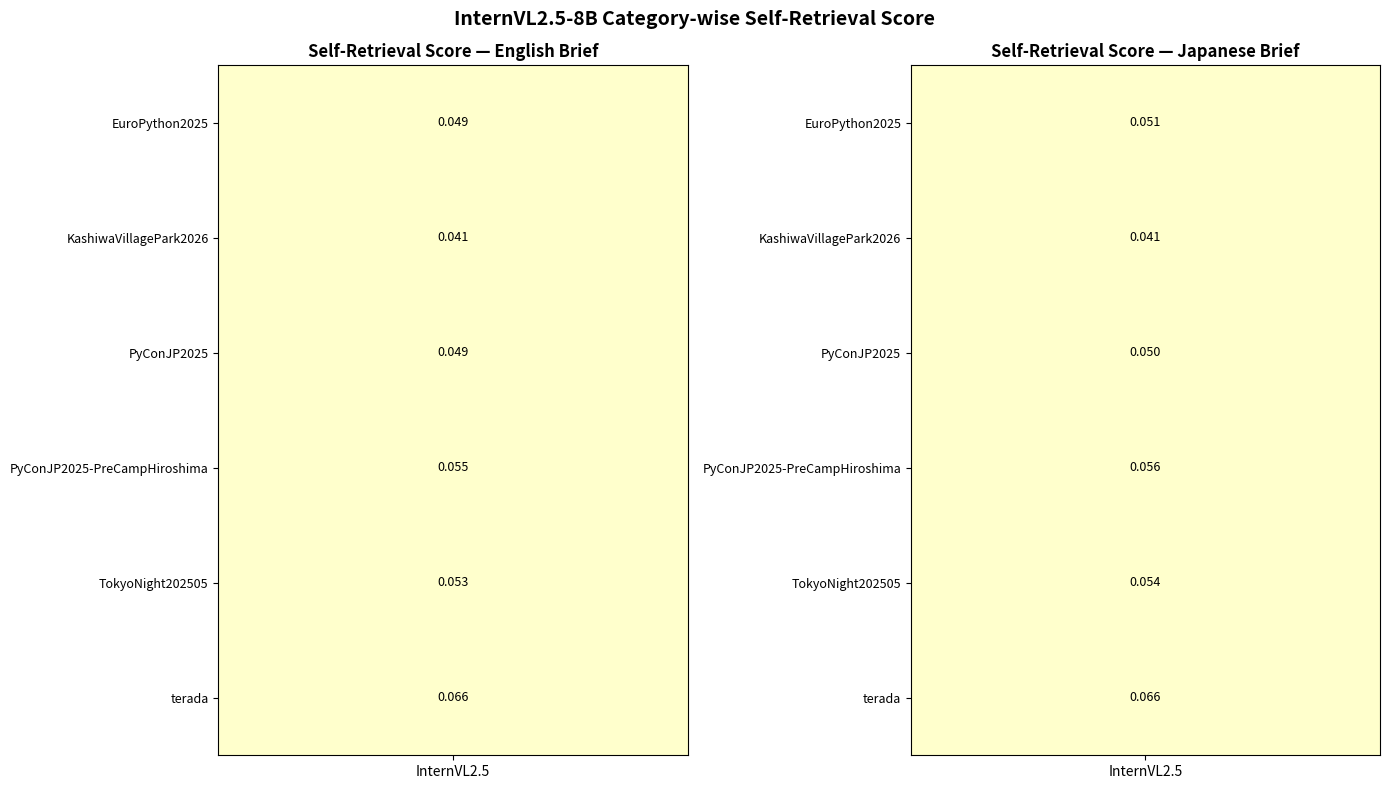

Saved: data/75_internvl_category_heatmap.png


In [17]:
# InternVL のカテゴリ別 Self-Retrieval Score
internvl_cat_sr = sr_df.groupby('category')[list(prompt_configs.keys())].mean()

# EN brief と JA brief のヒートマップ
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, key, title in [
    (axes[0], 'en_brief', 'English Brief'),
    (axes[1], 'ja_brief', 'Japanese Brief'),
]:
    heatmap_data = internvl_cat_sr[[key]].copy()
    heatmap_data.columns = ['InternVL2.5']
    
    im = ax.imshow(heatmap_data.values, cmap='YlOrRd', aspect='auto', vmin=0.15, vmax=0.45)
    
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index, fontsize=9)
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns, fontsize=10)
    ax.set_title(f'Self-Retrieval Score — {title}', fontsize=12, fontweight='bold')
    
    # 値をセルに表示
    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9,
                    color='white' if val > 0.35 else 'black')

plt.suptitle('InternVL2.5-8B Category-wise Self-Retrieval Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/75_internvl_category_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/75_internvl_category_heatmap.png")

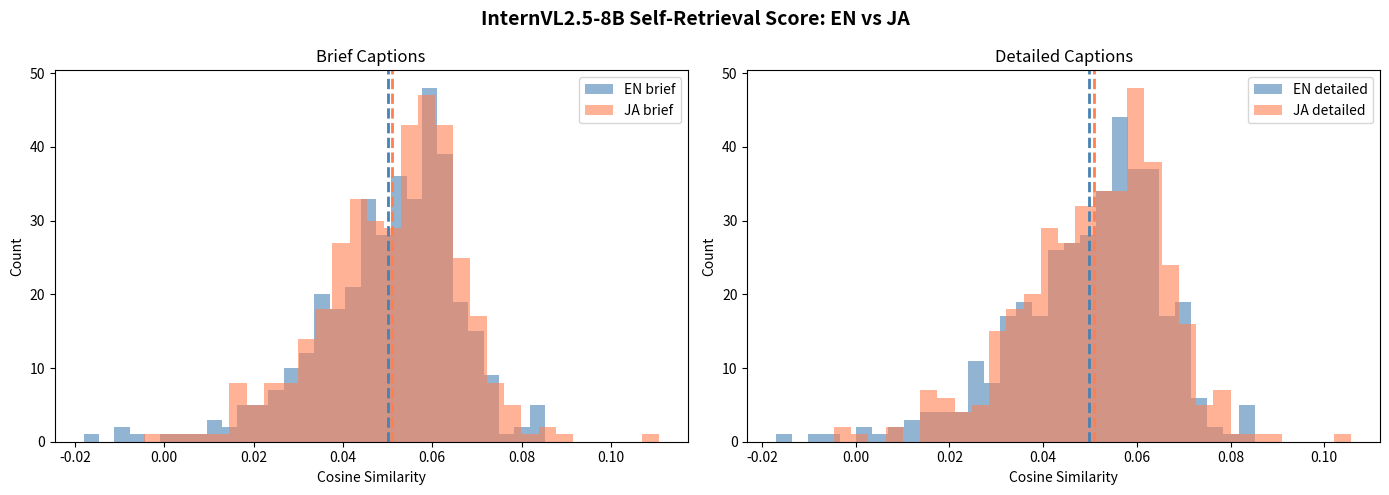

Saved: data/75_internvl_self_retrieval_en_vs_ja.png


In [18]:
# EN vs JA の Self-Retrieval Score 分布（Qwen2.5-VL との比較パターン）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brief
ax = axes[0]
ax.hist(self_retrieval['en_brief'], bins=30, alpha=0.6, label='EN brief', color='steelblue')
ax.hist(self_retrieval['ja_brief'], bins=30, alpha=0.6, label='JA brief', color='coral')
ax.axvline(self_retrieval['en_brief'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(self_retrieval['ja_brief'].mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Brief Captions')
ax.legend()

# Detailed
ax = axes[1]
ax.hist(self_retrieval['en_detailed'], bins=30, alpha=0.6, label='EN detailed', color='steelblue')
ax.hist(self_retrieval['ja_detailed'], bins=30, alpha=0.6, label='JA detailed', color='coral')
ax.axvline(self_retrieval['en_detailed'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(self_retrieval['ja_detailed'].mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Detailed Captions')
ax.legend()

plt.suptitle('InternVL2.5-8B Self-Retrieval Score: EN vs JA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/75_internvl_self_retrieval_en_vs_ja.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/75_internvl_self_retrieval_en_vs_ja.png")

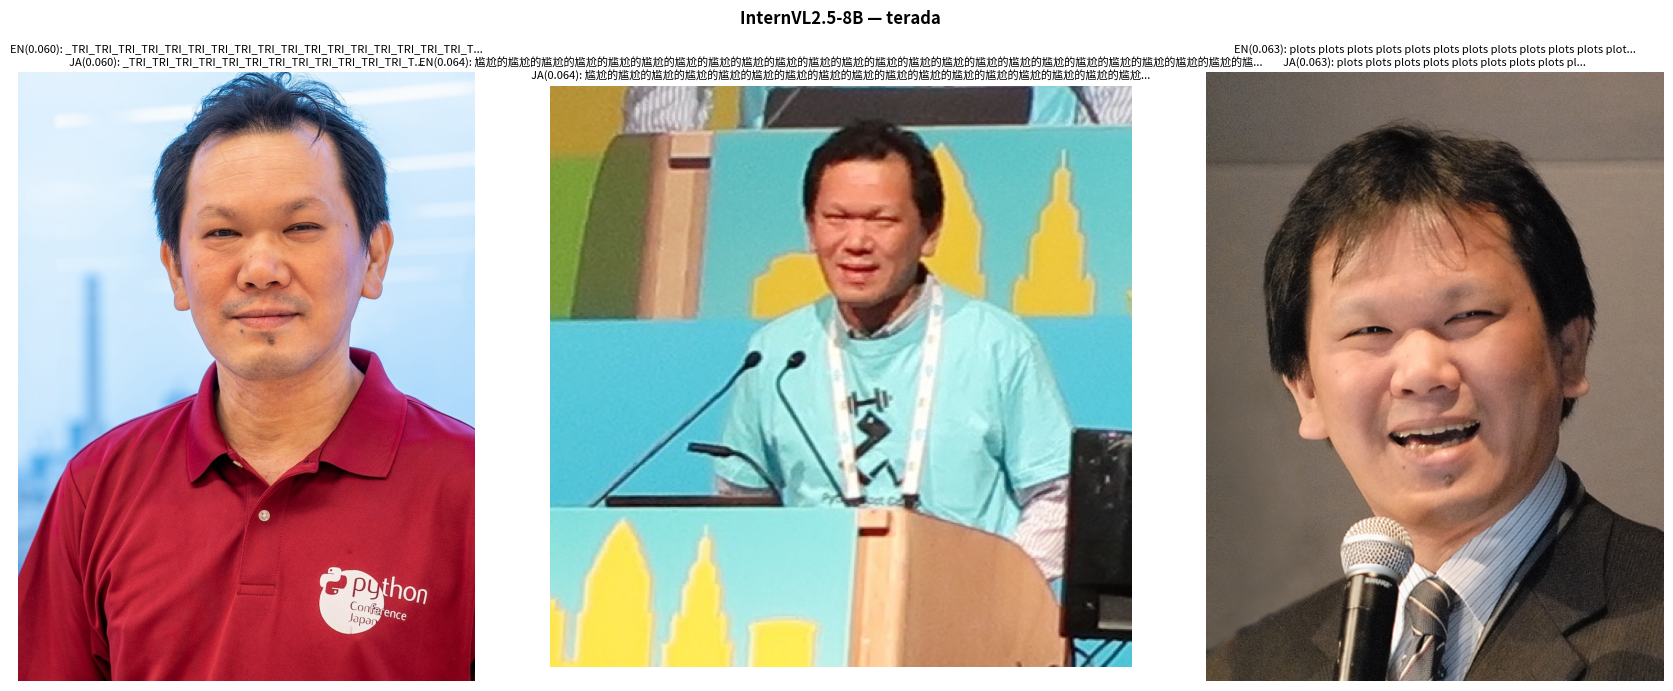

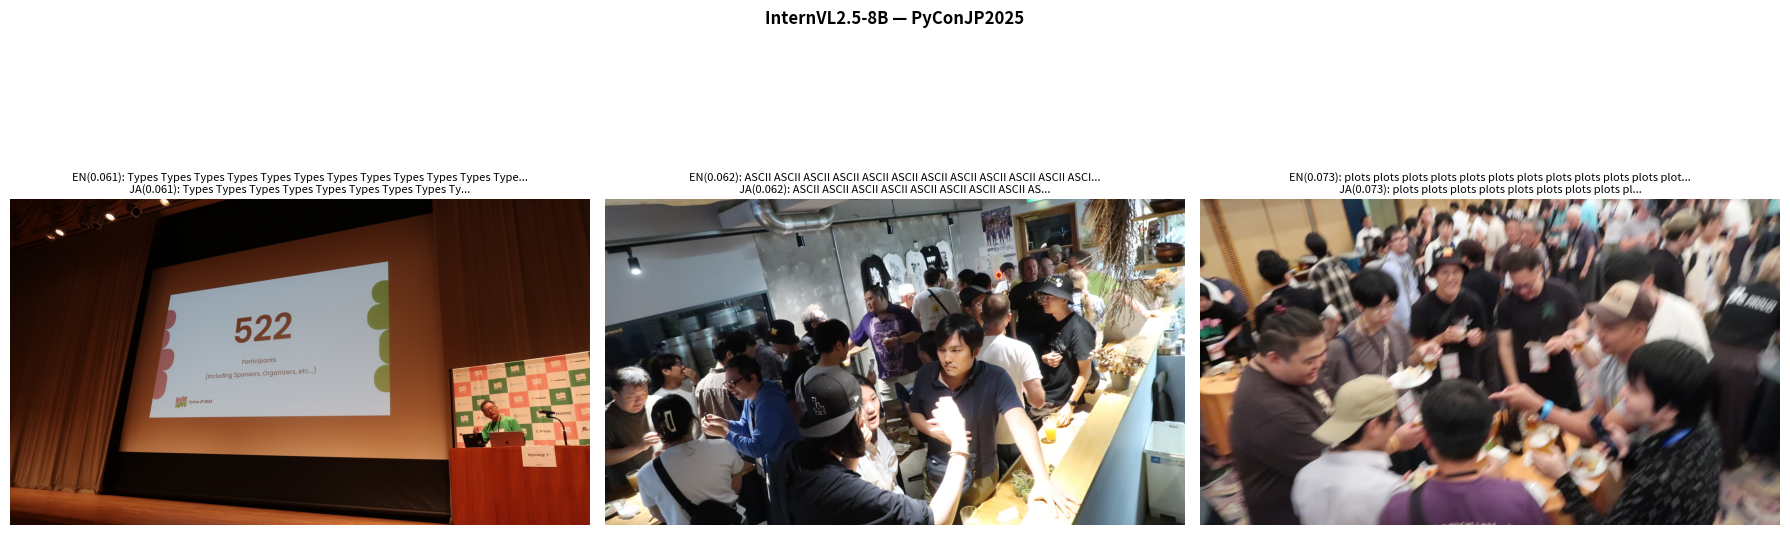

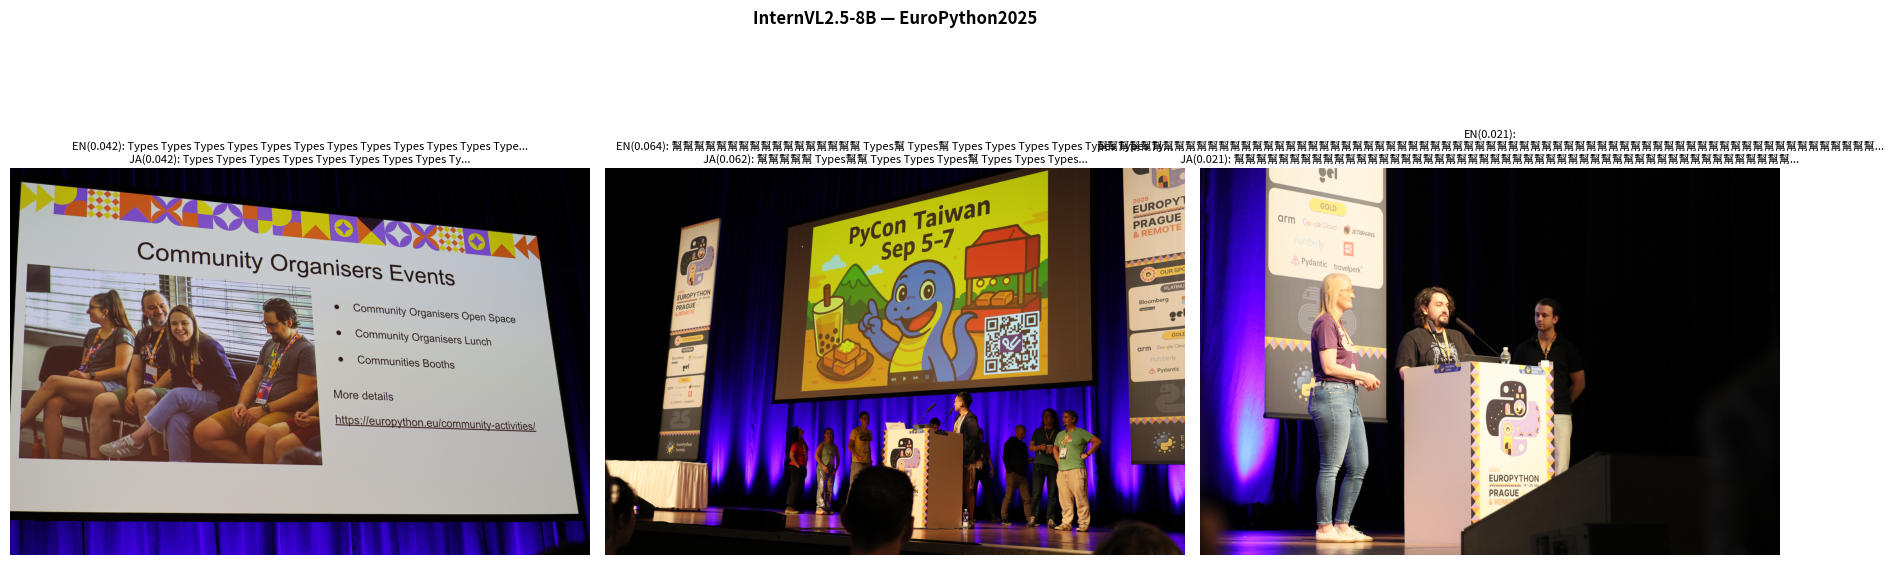

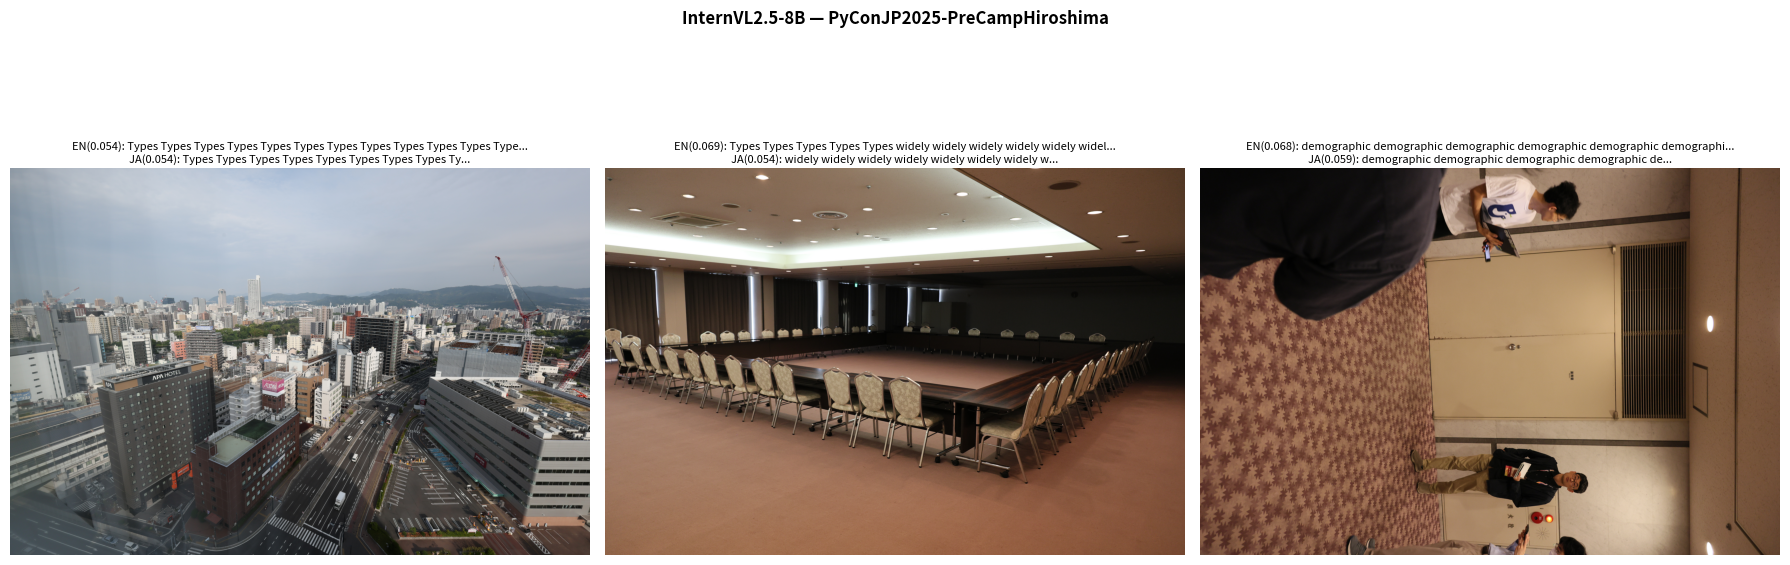

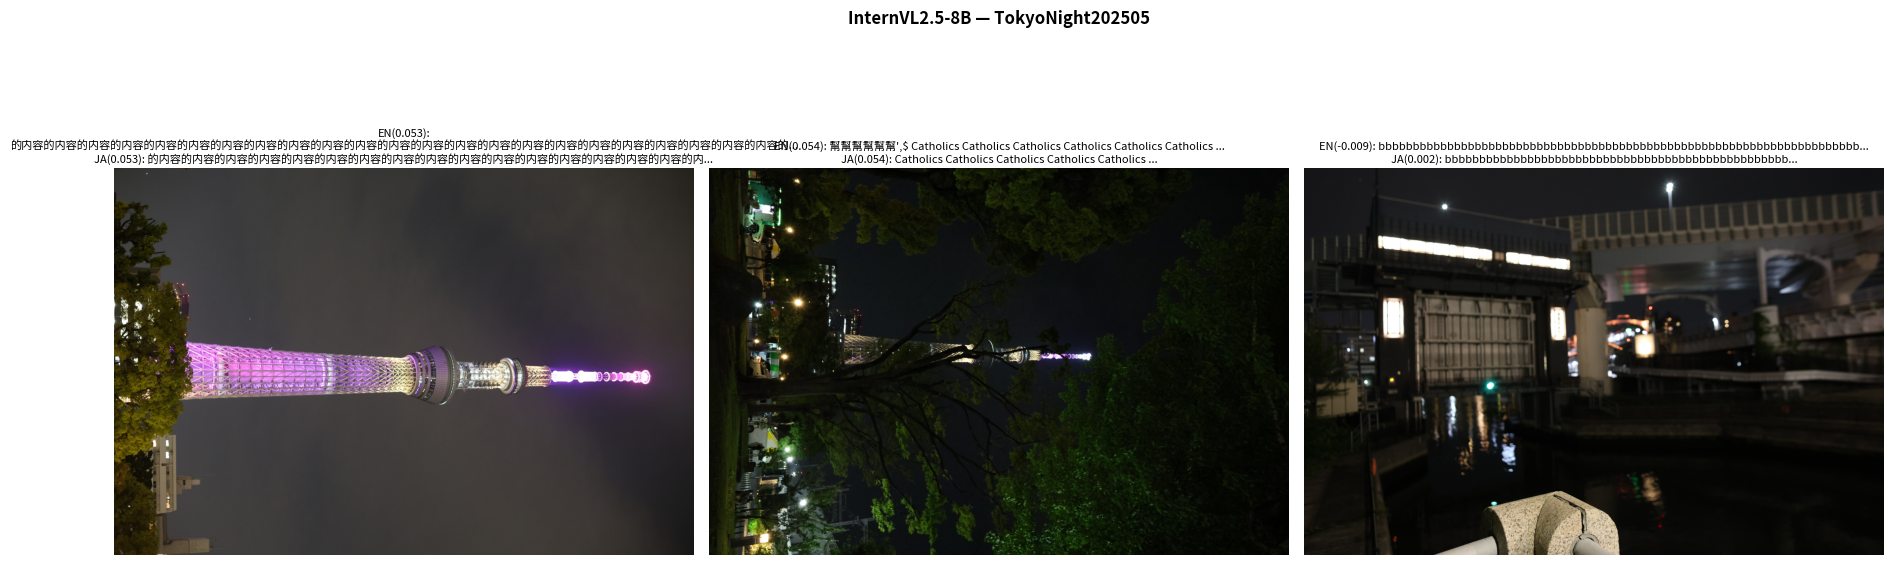

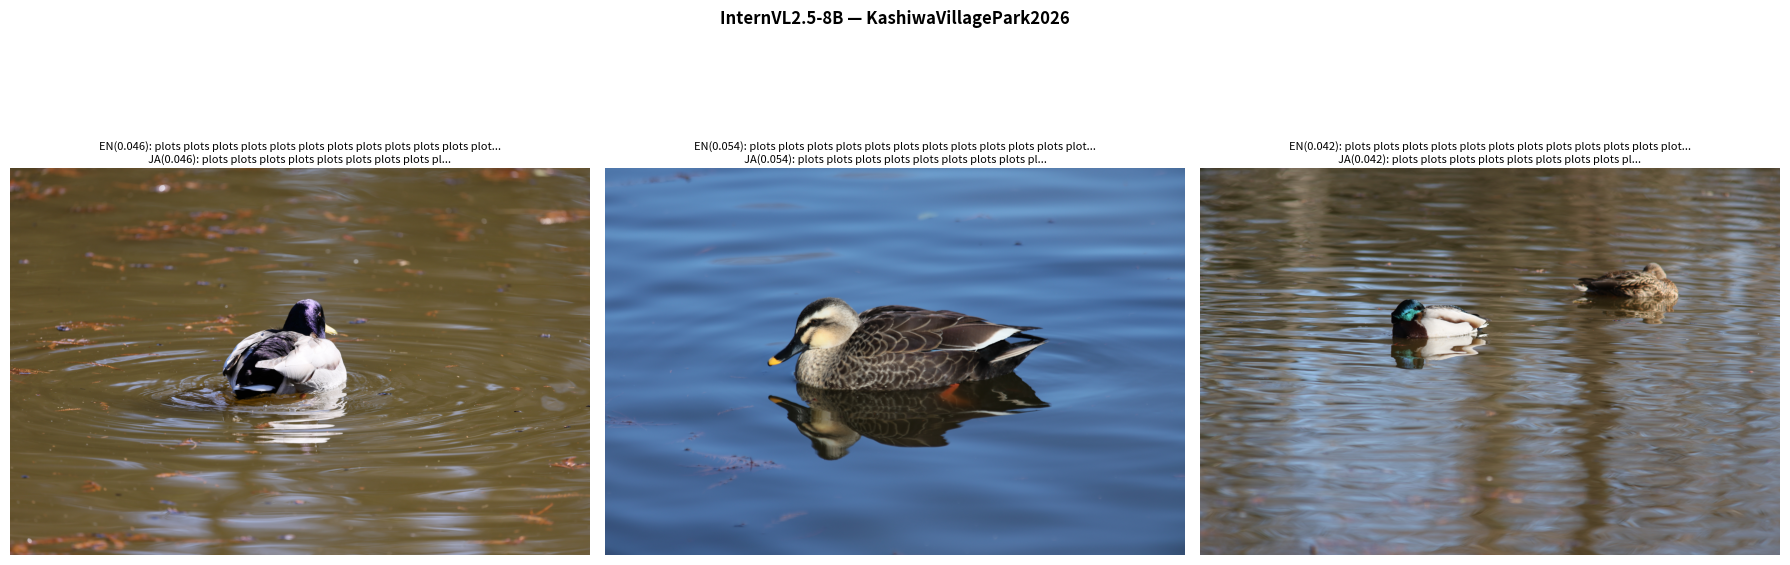

In [19]:
# 画像とキャプションの視覚的確認（日英並列）
for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:3]
    
    fig, axes = plt.subplots(1, len(cat_indices), figsize=(6 * len(cat_indices), 7))
    if len(cat_indices) == 1:
        axes = [axes]
    
    for i, idx in enumerate(cat_indices):
        row = catalog_df.iloc[idx]
        try:
            img = Image.open(row['file_path'])
            axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        
        en_cap = all_captions['en_brief'][idx][:70]
        ja_cap = all_captions['ja_brief'][idx][:50]
        sr_en = self_retrieval['en_brief'][idx]
        sr_ja = self_retrieval['ja_brief'][idx]
        
        title = f"EN({sr_en:.3f}): {en_cap}...\nJA({sr_ja:.3f}): {ja_cap}..."
        axes[i].set_title(title, fontsize=8, wrap=True)
        axes[i].axis('off')
    
    plt.suptitle(f'InternVL2.5-8B — {cat}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

## 11. DuckDB にキャプションを保存

In [20]:
conn = duckdb.connect(str(DB_PATH))

conn.execute("""
    CREATE TABLE IF NOT EXISTS image_captions (
        image_id VARCHAR,
        model_name VARCHAR,
        caption_en TEXT,
        caption_ja TEXT,
        prompt_template VARCHAR,
        timestamp TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        PRIMARY KEY (image_id, model_name, prompt_template)
    )
""")

conn.execute("DELETE FROM image_captions WHERE model_name = ?", [INTERNVL_MODEL])

# brief キャプション（日英）を保存
for idx in range(len(catalog_df)):
    image_id = catalog_df.iloc[idx]['id']
    caption_en = all_captions['en_brief'][idx]
    caption_ja = all_captions['ja_brief'][idx]
    
    conn.execute("""
        INSERT INTO image_captions (image_id, model_name, caption_en, caption_ja, prompt_template)
        VALUES (?, ?, ?, ?, 'brief')
    """, [image_id, INTERNVL_MODEL, caption_en, caption_ja])

# detailed キャプション（日英）も保存
for idx in range(len(catalog_df)):
    image_id = catalog_df.iloc[idx]['id']
    caption_en = all_captions['en_detailed'][idx]
    caption_ja = all_captions['ja_detailed'][idx]
    
    conn.execute("""
        INSERT INTO image_captions (image_id, model_name, caption_en, caption_ja, prompt_template)
        VALUES (?, ?, ?, ?, 'detailed')
    """, [image_id, INTERNVL_MODEL, caption_en, caption_ja])

conn.commit()

count = conn.execute(
    "SELECT COUNT(*) FROM image_captions WHERE model_name = ?", [INTERNVL_MODEL]
).fetchone()[0]
print(f"Stored {count} captions for model '{INTERNVL_MODEL}'")

all_counts = conn.execute(
    "SELECT model_name, COUNT(*) FROM image_captions GROUP BY model_name"
).fetchall()
print("\nAll models in image_captions:")
for m, c in all_counts:
    print(f"  {m}: {c}")

conn.close()

Stored 756 captions for model 'OpenGVLab/InternVL2_5-8B'

All models in image_captions:
  Qwen/Qwen2.5-VL-7B-Instruct: 756
  Salesforce/blip2-opt-2.7b: 378
  OpenGVLab/InternVL2_5-8B: 756


## 12. 結果の保存

In [21]:
output_data = {
    "notebook": "75-internvl-and-model-comparison",
    "model_name": INTERNVL_MODEL,
    "eval_model": SIGLIP2_MODEL,
    "timestamp": datetime.now().isoformat(),
    "total_images": len(catalog_df),
    "self_retrieval": {
        key: {
            "mean": float(self_retrieval[key].mean()),
            "std": float(self_retrieval[key].std()),
        }
        for key in prompt_configs
    },
    "retrieval_rank": {
        key: {
            "mean_rank": float(retrieval_results[key].mean()),
            "mrr": float((1.0 / retrieval_results[key]).mean()),
            "rank_at_1_ratio": float((retrieval_results[key] == 1).mean()),
        }
        for key in retrieval_results
    },
    "comparison": {
        row['Model']: {
            "sr_en": row['SR (EN best)'],
            "sr_ja": row['SR (JA best)'],
            "mrr_en": row['MRR (EN)'],
            "mrr_ja": row['MRR (JA)'],
            "speed_img_per_sec": row['Speed (img/s)'],
            "vram": row['VRAM (GB)'],
            "ja_support": row['JA support'],
        }
        for _, row in comparison_df.iterrows()
    },
    "processing_time_seconds": elapsed,
}

output_path = Path("../data/evaluations") / f"75_internvl_comparison_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/75_internvl_comparison_2026-02-20.json


## 13. GPU メモリのクリーンアップ

In [22]:
del embedder

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

InternVL2.5-8B (`OpenGVLab/InternVL2_5-8B`) で日英バイリンガルキャプションの生成を試み、
Notebook 72-74 の全モデルと総合比較を行った。

### InternVL2.5-8B の実行結果：生成失敗

**InternVL2.5-8B は transformers 5.x 環境下で正常なキャプションを生成できなかった。**

出力は `_TRI_TRI_TRI...`、`Types Types Types...`、`幫幫幫...`、`尴尬的尴尬的...` 等の
無意味なトークン繰り返しとなり、画像内容を一切反映していない。

#### 原因分析

InternVL2.5 のカスタムモデルコード（`trust_remote_code=True` で読み込み）は
transformers 4.x 向けに書かれており、以下の互換性問題が発生した：

1. **`all_tied_weights_keys` 未定義**: `InternVLChatModel.__init__` が `self.post_init()` を呼ばず、transformers 5.x で必須の属性が未設定 → 手動追加で修正
2. **`GenerationMixin` 未継承**: `InternLM2ForCausalLM` が `generate()` メソッドを持たない → `GenerationMixin` 多重継承で修正
3. **`clean_up_tokenization` 削除**: transformers 5.x でトークナイザの当該メソッドが廃止 → 該当呼び出しを削除
4. **`Tensor.item()` on meta tensors**: `modeling_intern_vit.py` で meta テンソルに `.item()` を呼び出し → `torch.linspace(..., device='cpu').tolist()` に修正

上記の修正でモデルのロードとテキスト生成は動作するようになったが、
**生成されたトークン列が完全に壊れている**。これは：
- トークナイザの `convert_tokens_to_string` が正しく動作していない可能性
- `InternLM2ForCausalLM` の `generate()` の挙動が transformers 5.x で変わった可能性
- カスタムの `chat()` メソッド内のテンプレート処理が不整合を起こしている可能性

が考えられる。根本的な修正には InternVL2.5 のモデルコード全体を transformers 5.x に対応させる必要がある。

### 総合比較結果（有効なモデルのみ）

| モデル | SR (EN) | SR (JA) | MRR (EN) | MRR (JA) | JA対応 | VRAM | 速度 |
|--------|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| BLIP-2 (NB72) | 0.161 | — | 0.435 | — | No | ~6GB | 2.62 img/s |
| Qwen2.5-VL (NB74) | **0.180** | **0.138** | **0.635** | **0.318** | **Yes** | ~15GB | 0.03 img/s |
| InternVL2.5-8B (NB75) | 0.050 | 0.051 | 0.017 | 0.017 | Yes* | ~18GB | 0.04 img/s |

*InternVL2.5 は生成失敗のため数値に意味がない（ランダム以下）

### 考察

1. **Qwen2.5-VL が唯一の実用的な多言語VLM**
   - EN MRR 0.635（Rank@1: 50.5%）は BLIP-2（0.435, 27.2%）を大きく上回る
   - JA 対応を含め、現環境で最も実用的なキャプションモデル

2. **InternVL2.5 は transformers 5.x 非対応**
   - 4つの互換性問題を手動修正したが、生成品質は回復せず
   - 公式の transformers 5.x 対応が必要（2026年2月時点で未対応）
   - **本ノートブックの InternVL2.5 の数値は評価対象外とする**

3. **BLIP-2 は英語専用だが安定**
   - SR 0.161, MRR 0.435 は英語キャプションとして一定の品質
   - VRAM ~6GB と軽量、速度も 2.62 img/s と最速
   - 日本語不要なら十分な選択肢

4. **Florence-2 (NB73) と ColPali (NB77) もスキップ**
   - Florence-2: transformers 5.x の `additional_special_tokens` / `forced_bos_token_id` 非互換
   - ColPali: `colpali-engine` が `transformers<4.58.0` を要求
   - **transformers 5.x への移行期に多くのVLMが非互換を起こしている**

5. **結論**
   - **日本語対応が必要**: Qwen2.5-VL-7B（唯一の選択肢）
   - **英語のみ・軽量**: BLIP-2（安定、高速、低VRAM）
   - 今後 InternVL2.5 / Florence-2 の公式 transformers 5.x 対応を待って再評価が望ましい